Importing Libraries

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from IPython.display import display
from sklearn.preprocessing import LabelEncoder

Loading dataset

In [158]:
df = pd.read_csv("C:\\Users\\AswathKS\\Desktop\\EDA\\Dataset\\9_energy_consumption.csv")

Understanding dataset

In [159]:
display(df.shape)
df.info()
df.isnull().sum()

(15000, 38)

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   household_id                15000 non-null  str    
 1   household_size              15000 non-null  int64  
 2   num_adults                  15000 non-null  int64  
 3   num_children                15000 non-null  int64  
 4   home_ownership              15000 non-null  str    
 5   house_type                  15000 non-null  str    
 6   income_bracket              15000 non-null  str    
 7   square_footage              14400 non-null  float64
 8   num_bedrooms                15000 non-null  int64  
 9   num_bathrooms               15000 non-null  float64
 10  house_age_years             15000 non-null  int64  
 11  insulation_quality          15000 non-null  str    
 12  num_floors                  15000 non-null  int64  
 13  has_basement                15000 non-null

household_id                     0
household_size                   0
num_adults                       0
num_children                     0
home_ownership                   0
house_type                       0
income_bracket                   0
square_footage                 600
num_bedrooms                     0
num_bathrooms                    0
house_age_years                  0
insulation_quality               0
num_floors                       0
has_basement                     0
heating_type                     0
cooling_type                  1561
thermostat_setting_winter      600
thermostat_setting_summer        0
climate_zone                     0
num_refrigerators                0
has_dishwasher                   0
has_washer_dryer                 0
has_electric_water_heater        0
has_pool                         0
has_spa_hot_tub                  0
num_tvs                          0
num_computers                    0
has_smart_thermostat             0
has_led_lighting    

Handling NULL

In [160]:
# Numeric → median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
 
# Categorical → mode
cat_cols = df.select_dtypes(include=['str']).columns
for col in cat_cols: 
     df[col]=df[col].fillna(df[col].mode()[0])

In [161]:
df.isnull().sum()

household_id                  0
household_size                0
num_adults                    0
num_children                  0
home_ownership                0
house_type                    0
income_bracket                0
square_footage                0
num_bedrooms                  0
num_bathrooms                 0
house_age_years               0
insulation_quality            0
num_floors                    0
has_basement                  0
heating_type                  0
cooling_type                  0
thermostat_setting_winter     0
thermostat_setting_summer     0
climate_zone                  0
num_refrigerators             0
has_dishwasher                0
has_washer_dryer              0
has_electric_water_heater     0
has_pool                      0
has_spa_hot_tub               0
num_tvs                       0
num_computers                 0
has_smart_thermostat          0
has_led_lighting              0
has_energy_star_appliances    0
has_solar_panels              0
energy_a

Finding Dup

In [162]:
df.duplicated().sum()
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14995    False
14996    False
14997    False
14998    False
14999    False
Length: 15000, dtype: bool

Drop COL

In [163]:
df = df.drop(columns=['household_id'])

Handling Bathrooms

In [164]:
df['num_bathrooms'] = df['num_bathrooms'].round(1).astype(int)

In [165]:
df['num_bathrooms'].head(10)

0    3
1    4
2    2
3    1
4    3
5    1
6    2
7    1
8    3
9    2
Name: num_bathrooms, dtype: int64

In [166]:
display(df['num_bathrooms'])

0        3
1        4
2        2
3        1
4        3
        ..
14995    3
14996    3
14997    3
14998    1
14999    1
Name: num_bathrooms, Length: 15000, dtype: int64

Combining Features

In [168]:

# Area per person
df["area_per_person"] = df["square_footage"] / df["household_size"]
 
# Bathroom per bedroom ratio
df["bath_bed_ratio"] = df["num_bathrooms"] / df["num_bedrooms"]
 
# Temperature difference
df["temp_diff"] = df["thermostat_setting_summer"] - df["thermostat_setting_winter"]
 
# Appliance count
df["appliance_count"] = df["num_tvs"] + df["num_computers"] + df["num_refrigerators"]

 
display(df[[
    "area_per_person",
    "bath_bed_ratio",
    "temp_diff",
    "appliance_count"
]].head(10))

,area_per_person,bath_bed_ratio,temp_diff,appliance_count
0,551.00,0.600000,8.0,6
1,696.75,0.800000,3.0,10
2,549.50,1.000000,6.0,5
3,1298.00,1.000000,8.0,11
4,554.50,1.000000,9.0,7
5,1344.00,0.500000,6.0,6
6,802.50,0.666667,2.0,9
7,887.00,1.000000,-3.0,8
8,542.00,0.750000,-1.0,5
9,582.00,1.000000,3.0,6


Applying labled_encoding to yes,no

In [169]:
yes_no_cols = [
    'has_basement', 'has_dishwasher', 'has_washer_dryer',
    'has_electric_water_heater', 'has_pool', "has_spa_hot_tub", 'has_smart_thermostat',
    'has_led_lighting', 'has_energy_star_appliances',
    'has_solar_panels', 'energy_audit_done', 'works_from_home',
    'high_consumption'
]

for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
 
df[yes_no_cols].head()
 

,has_basement,has_dishwasher,has_washer_dryer,has_electric_water_heater,has_pool,has_spa_hot_tub,has_smart_thermostat,has_led_lighting,has_energy_star_appliances,has_solar_panels,energy_audit_done,works_from_home,high_consumption
0,1,0,1,0,0,0,0,1,1,0,1,0,1
1,0,0,1,0,0,0,1,1,1,0,1,0,1
2,0,0,1,0,0,0,0,0,1,0,0,0,0
3,1,1,1,0,0,0,0,1,1,0,0,0,0
4,0,1,1,0,0,0,1,1,1,0,1,0,0


Applying One_Hot Encoding to cat

In [170]:
# removing binary columns from cat list
binary_cols = [
    'has_basement', 'has_dishwasher', 'has_washer_dryer',
    'has_electric_water_heater', 'has_pool', "has_spa_hot_tub", 'has_smart_thermostat',
    'has_led_lighting', 'has_energy_star_appliances',
    'has_solar_panels', 'energy_audit_done', 'works_from_home',
    'high_consumption'
]
 
cat_cols = df.select_dtypes(include='object').columns
cat_cols = [col for col in cat_cols if col not in binary_cols]

# apply encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

C:\Users\AswathKS\AppData\Local\Temp\ipykernel_4340\2362642475.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [171]:
df.head()

,household_size,num_adults,num_children,square_footage,num_bedrooms,num_bathrooms,house_age_years,num_floors,has_basement,thermostat_setting_winter,...,heating_type_Oil,heating_type_Other,cooling_type_Heat Pump,cooling_type_Window Units,climate_zone_Hot,climate_zone_Mixed,climate_zone_Moderate,peak_usage_time_Evening,peak_usage_time_Morning,peak_usage_time_Night
0,5,5,0,2755.0,5,3,8,2,1,68.0,...,False,False,False,False,False,True,False,True,False,False
1,4,3,1,2787.0,5,4,81,1,0,74.0,...,False,False,False,True,True,False,False,True,False,False
2,2,2,0,1099.0,2,2,62,2,0,66.0,...,False,False,False,False,True,False,False,False,True,False
3,1,1,0,1298.0,1,1,1,2,1,64.0,...,False,False,False,False,False,True,False,False,False,False
4,2,1,1,1109.0,3,3,2,2,0,67.0,...,False,False,False,False,False,False,True,False,True,False


In [172]:
df[['high_consumption']].head()

,high_consumption
0,1
1,1
2,0
3,0
4,0


Performing EDA

Hight vs Low

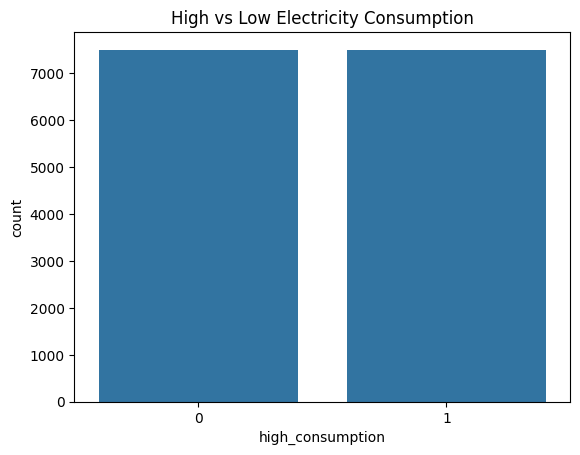

In [173]:
import seaborn as sns
import matplotlib.pyplot as plt
 
sns.countplot(x="high_consumption", data=df)
plt.title("High vs Low Electricity Consumption")
plt.show()

Distribution of Electricity Consumption

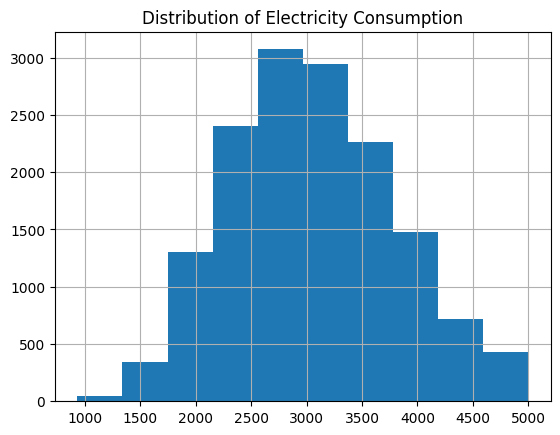

In [174]:
df["monthly_kwh_consumption"].hist()
plt.title("Distribution of Electricity Consumption")
plt.show()

Correlation heatmap

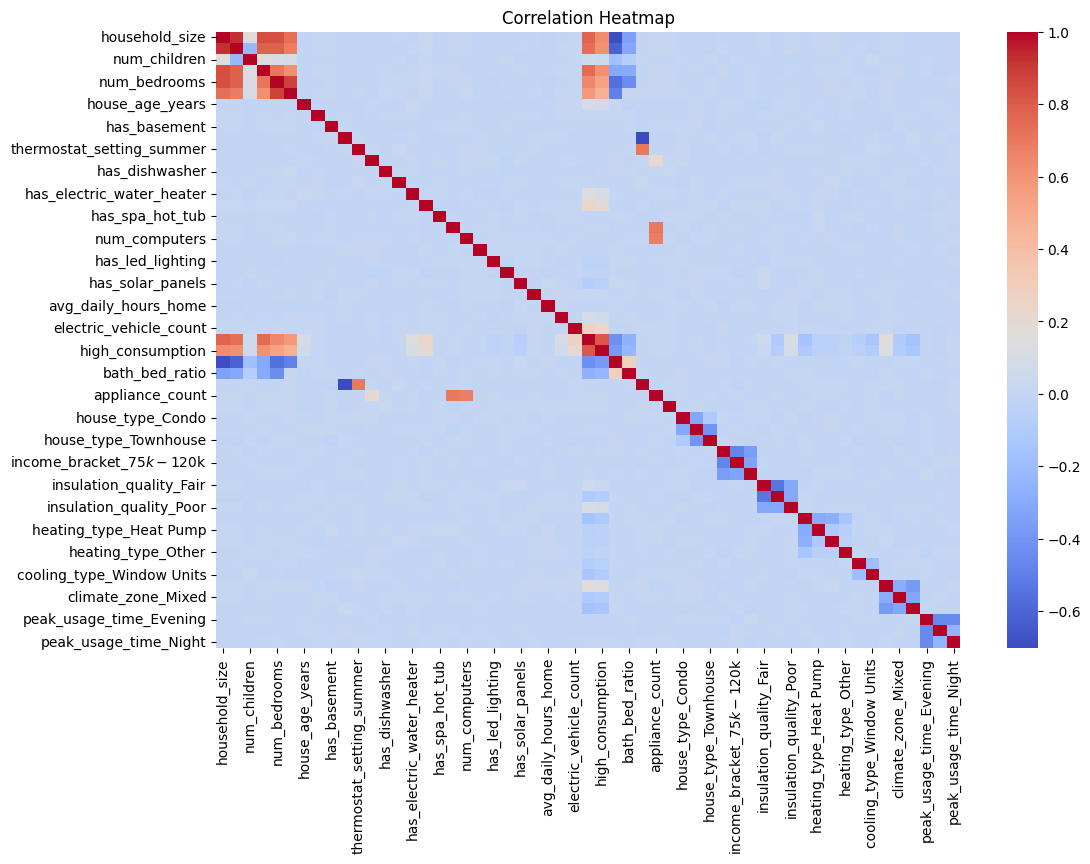

In [175]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

House size vs consumption

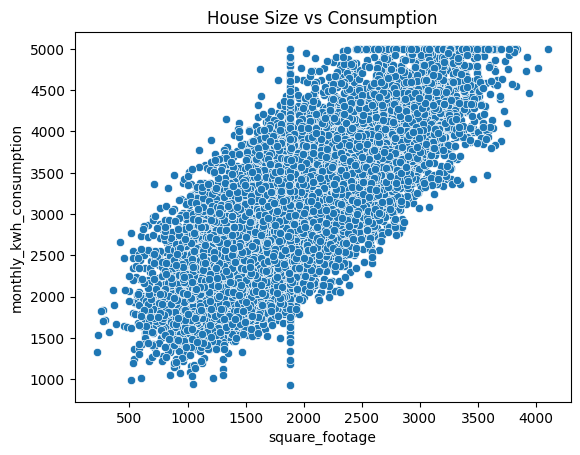

In [176]:
sns.scatterplot(x="square_footage", y="monthly_kwh_consumption", data=df)
plt.title("House Size vs Consumption")
plt.show()

Family size vs Consumption

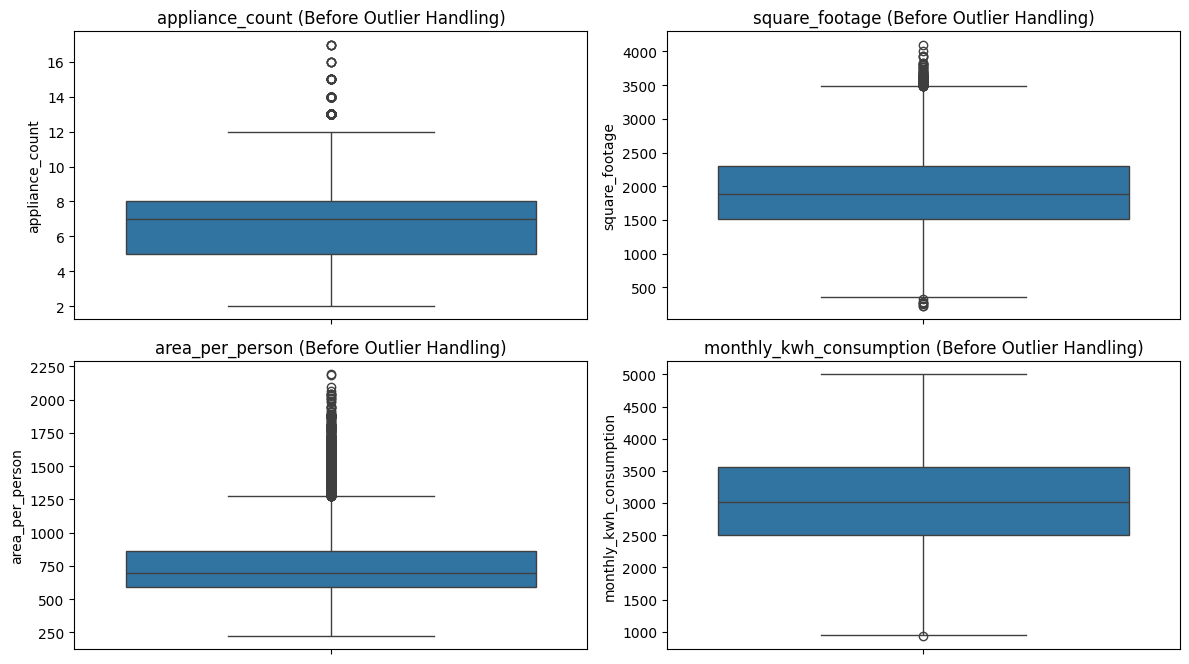

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
 
features = [
    "appliance_count",
    "square_footage",
    "area_per_person",
    "monthly_kwh_consumption"
]
 
plt.figure(figsize=(12,10))
 
for i, col in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f"{col} (Before Outlier Handling)")

plt.tight_layout()
plt.show()

In [181]:
# Function to handle outliers using IQR
def handle_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # Capping
        df[col] = df[col].clip(lower, upper)
    return df
# Apply
cols = [
    "appliance_count",
    "square_footage",
    "area_per_person",
    "monthly_kwh_consumption"
]
df = handle_outliers(df, cols)

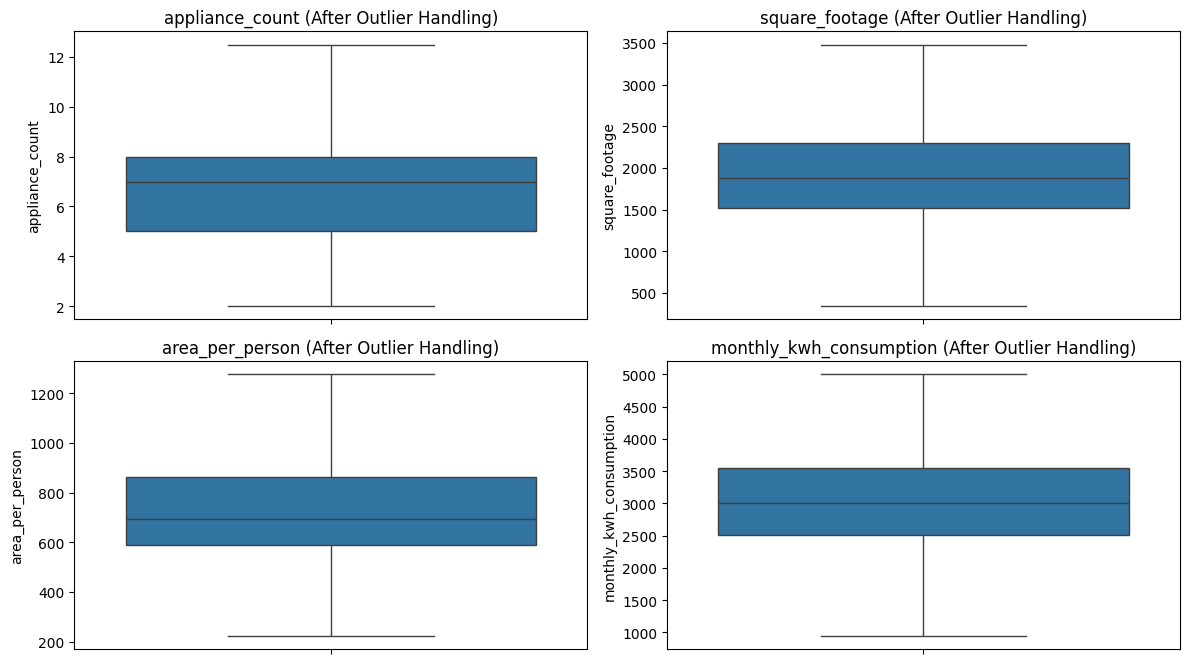

In [182]:
plt.figure(figsize=(12,10))
 
for i, col in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f"{col} (After Outlier Handling)")
plt.tight_layout()
plt.show()